In [210]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [211]:
data = pd.read_csv("Randomized Data - Copy.csv")
A = data.pop("A")
Z = data.pop("Z")
N = data.pop("N")
y = np.array((data.pop("BE")))
BE_A = data.pop("BE/A")
x= np.array((data))
print(x.shape)

(3354, 5)


In [212]:
w_init = np.array((15.75, -17.8, -0.711, -23.7,11.18))

In [213]:
LDMD = []
for i in range(x.shape[0]):
    tmp = np.dot(x[i], w_init)
    LDMD.append(tmp)

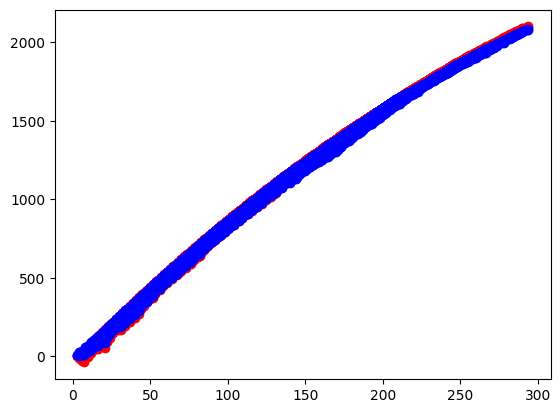

In [214]:
plt.scatter(A, LDMD, color="red")
plt.scatter(A, y, color="blue")

In [215]:
X_train = x[:2012]
Y_train = y[:2012]
X_test = np.array(x[2012:])
Y_test = y[2012:]

In [216]:
model = LinearRegression(fit_intercept=False)
model.fit(X_train, Y_train)
w = model.coef_

In [217]:
print("Coefficients:", w)

Coefficients: [ 15.25561479 -16.2500258   -0.68837504 -22.17336291  11.48861481]


In [218]:
y_pred = model.predict(X_test)
# Mean Squared Error (MSE)
mse = mean_squared_error(Y_test, y_pred)
# Mean Absolute Error (MAE)
mae = mean_absolute_error(Y_test, y_pred)

print("MSE", mse)
print("MAE", mae)

MSE 15.434425807347983
MAE 2.834218651020751


In [219]:
predictions = []
tmp = A[2012:]
for i in range(X_test.shape[0]):
    v = np.dot(X_test[i],w)
    predictions.append(v)

In [220]:
predictions_A = []
tmp = A[2012:]
for i in range(X_test.shape[0]):
    v = np.dot(X_test[i],w)/ A[2012+i]
    predictions_A.append(v)

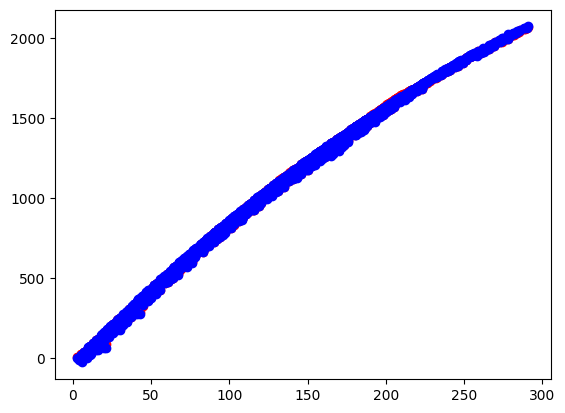

In [221]:
plt.scatter(A[2012:], Y_test, color="red")
plt.scatter(A[2012:], predictions, color="blue")

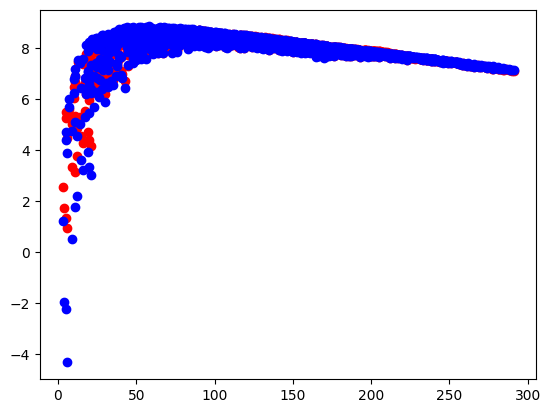

In [222]:
plt.scatter(A[2012:], BE_A[2012:], color="red")
plt.scatter(A[2012:], predictions_A, color="blue")

In [223]:
BE_A_Pred = []
for i in range(x.shape[0]):
    v = np.dot(x[i],w)
    BE_A_Pred.append(v)

BE_A_Pred = np.array((BE_A_Pred))
print(y.shape)
print(BE_A_Pred.shape)

(3354,)
(3354,)


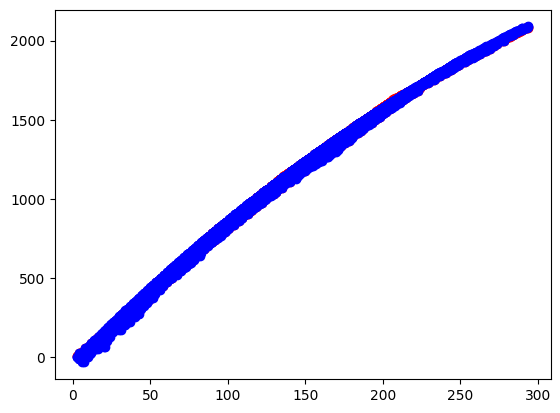

In [224]:
#Prediction
plt.scatter(A, y, color="red")
plt.scatter(A, BE_A_Pred, color="blue")

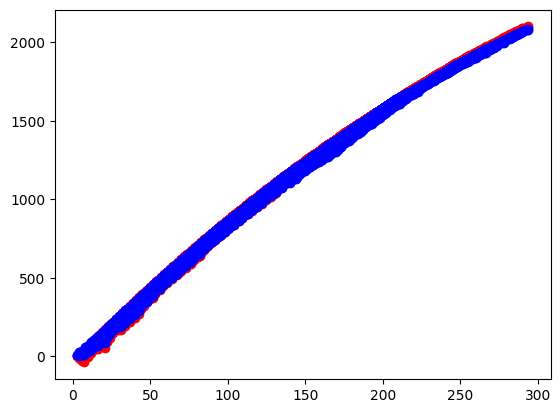

In [225]:
#Current Values
plt.scatter(A, LDMD, color="red")
plt.scatter(A, y, color="blue")